In [ ]:
import numpy as np
import pandas as pd
import librosa
import os
import torch
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GRU, Dense, Dropout, Flatten, MaxPooling1D, BatchNormalization
from tensorflow.keras.activations import swish
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load Wav2Vec2.0 model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:312: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

In [ ]:
# Set directories
main_dir = "/content/drive/MyDrive/Colab Notebooks/5T/data"
labels = os.listdir(main_dir)
x, y = [], []

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

In [ ]:
for label in labels:
    sub_dir = os.path.join(main_dir, label)
    files = os.listdir(sub_dir)
    for file in files:
        path = os.path.join(sub_dir, file)
        audio, sr = librosa.load(path, sr=16000)

        # Ensure minimum length for FFT
        min_length = 2048
        if len(audio) < min_length:
            audio = np.pad(audio, (0, min_length - len(audio)), mode='constant')

        # Dynamic FFT size
        n_fft = min(2048, len(audio) // 2)
        hop_length = n_fft // 4

        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=80, n_fft=n_fft, hop_length=hop_length)
        delta_mfcc = librosa.feature.delta(mfccs)
        delta2_mfcc = librosa.feature.delta(mfccs, order=2)

        features = np.vstack([mfccs, delta_mfcc, delta2_mfcc])
        mfccs_scaled = np.mean(features.T, axis=0)

        x.append(mfccs_scaled)
        y.append(label)

In [ ]:
# Encode Labels
le = LabelEncoder().fit(y)
y = le.transform(y)
np.save("label3.npy", le.classes_)

In [ ]:
# Split Data
x_train, x_test, y_train, y_test = train_test_split(np.array(x), np.array(y), test_size=0.2, random_state=42)
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)

In [ ]:
from tensorflow.keras.layers import GaussianNoise

# Apply Gaussian Noise to the input to improve generalization
model = Sequential()

# Convolutional Layers
model.add(Conv1D(128, 5, padding='same', input_shape=(x_train.shape[1], 1), kernel_regularizer=tf.keras.regularizers.l2(0.0005)))
model.add(BatchNormalization())
model.add(tf.keras.layers.LeakyReLU(alpha=0.01))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))  # Increased dropout

model.add(Conv1D(256, 5, padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.0005)))
model.add(BatchNormalization())
model.add(tf.keras.layers.LeakyReLU(alpha=0.01))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.4))  # Increased dropout

model.add(Conv1D(384, 3, padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.0005)))  # Reduced filters slightly
model.add(BatchNormalization())
model.add(tf.keras.layers.LeakyReLU(alpha=0.01))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))  # Increased dropout

# GRU Layers
model.add(GRU(192, activation='tanh', return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(0.0005)))  # Reduced units slightly
model.add(GRU(128, activation='tanh', return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(0.0005)))
model.add(GRU(96, activation='tanh', kernel_regularizer=tf.keras.regularizers.l2(0.0005)))
model.add(Dropout(0.5))  # Increased dropout

# Fully Connected Layers
model.add(Dense(512, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(0.0005)))  # L2 Regularization added
model.add(Dropout(0.6))
model.add(Dense(len(labels), activation='softmax'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
# Optimizer with Cosine Decay
cosine_decay = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.0005, decay_steps=10000, alpha=0.0001)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [ ]:
# Learning Rate Scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', patience=4, factor=0.5, min_lr=1e-5)

In [ ]:
# Train Model with Larger Batch Size
history = model.fit(x_train, y_train, batch_size=64, epochs=100, validation_data=(x_test, y_test), callbacks=[lr_scheduler])

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 99s 474ms/step - accuracy: 0.8299 - loss: 0.8364 - val_accuracy: 0.8749 - val_loss: 0.6716 - learning_rate: 5.0000e-04
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 141s 471ms/step - accuracy: 0.8494 - loss: 0.7705 - val_accuracy: 0.8765 - val_loss: 0.6692 - learning_rate: 5.0000e-04
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 141s 467ms/step - accuracy: 0.8387 - loss: 0.8017 - val_accuracy: 0.8795 - val_loss: 0.6600 - learning_rate: 5.0000e-04
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 141s 462ms/step - accuracy: 0.8488 - loss: 0.7798 - val_accuracy: 0.8795 - val_loss: 0.6836 - learning_rate: 5.0000e-04
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 147s 490ms/step - accuracy: 0.8516 - loss: 0.7822 - val_accuracy: 0.8765 - val_loss: 0.6908 - learning_rate: 5.0000e-04
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 137s 463ms/step - accuracy: 0.8527 - loss: 0.7850 - val_accuracy: 0.8743 - val_loss: 0.6801 - learning_rate: 5.0000e-04
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━

In [ ]:
# Compile Model
#model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), metrics=['accuracy'])

In [ ]:
# Callbacks (Reduce LR if no improvement)
#lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', patience=5, factor=0.5, min_lr=1e-5)

In [ ]:
# Train Model
#history = model.fit(x_train, y_train, batch_size=64, epochs=100, validation_data=(x_test, y_test), callbacks=[lr_scheduler])

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 125s 650ms/step - accuracy: 0.7959 - loss: 0.7575 - val_accuracy: 0.8208 - val_loss: 0.6536 - learning_rate: 5.0000e-04
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 118s 614ms/step - accuracy: 0.8460 - loss: 0.5833 - val_accuracy: 0.8651 - val_loss: 0.5212 - learning_rate: 5.0000e-04
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 143s 616ms/step - accuracy: 0.8667 - loss: 0.4708 - val_accuracy: 0.8743 - val_loss: 0.4581 - learning_rate: 5.0000e-04
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 144s 632ms/step - accuracy: 0.8806 - loss: 0.4342 - val_accuracy: 0.8612 - val_loss: 0.4736 - learning_rate: 5.0000e-04
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 142s 635ms/step - accuracy: 0.8969 - loss: 0.3527 - val_accuracy: 0.8664 - val_loss: 0.4790 - learning_rate: 5.0000e-04
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 140s 622ms/step - accuracy: 0.9056 - loss: 0.3267 - val_accuracy: 0.8684 - val_loss: 0.4639 - learning_rate: 5.0000e-04
Epoch 7/100
192/192 ━━━━━━━━━━━━━━

In [ ]:
# Evaluate Model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.9287 - loss: 0.4622
Test Accuracy: 93.36%
Test Loss: 0.4374


In [ ]:
# Save Model
model.save("AQUAMODEL3.keras")

In [ ]:
# Evaluate model
model.evaluate(x_test, y_test)

96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9287 - loss: 0.4622


[0.4374493956565857, 0.9335504770278931]

In [ ]:
# Training accuracy and loss over epochs
acc = history.history['accuracy'] # Changed detector to history
val_acc = history.history['val_accuracy'] # Changed detector to history
loss = history.history['loss'] # Changed detector to history
val_loss = history.history['val_loss'] # Changed detector to history

# Print final accuracy and loss values
print(f"Final Training Accuracy: {acc[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1] * 100:.2f}%")
print(f"Final Training Loss: {loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

Final Training Accuracy: 96.27%
Final Validation Accuracy: 93.36%
Final Training Loss: 0.3202
Final Validation Loss: 0.4374


In [ ]:
# Train model
detector = model.fit(x_train, y_train, batch_size=128, epochs=100, validation_data=(x_test, y_test))

Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.1955 - loss: 3.1740 - val_accuracy: 0.3339 - val_loss: 2.5637
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5027 - loss: 1.8112 - val_accuracy: 0.6274 - val_loss: 1.3468
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6768 - loss: 1.1935 - val_accuracy: 0.7362 - val_loss: 0.9510
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7684 - loss: 0.8688 - val_accuracy: 0.8091 - val_loss: 0.7413
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8152 - loss: 0.6948 - val_accuracy: 0.8121 - val_loss: 0.6934
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8357 - loss: 0.5993 - val_accuracy: 0.8326 - val_loss: 0.5960
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8664 - loss: 0.4985 - val_accuracy: 0.8655 - val_loss: 0.4976
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8790 - loss: 0.4333 - val_accuracy: 0

In [ ]:
# Evaluate model
model.evaluate(x_test, y_test)

96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9132 - loss: 0.4040


[0.37844711542129517, 0.9136807918548584]

In [ ]:
# Save trained model
model.save("aquatic_species_model.keras")  # Recommended format

In [ ]:
from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt #Importing matplotlib.pyplot


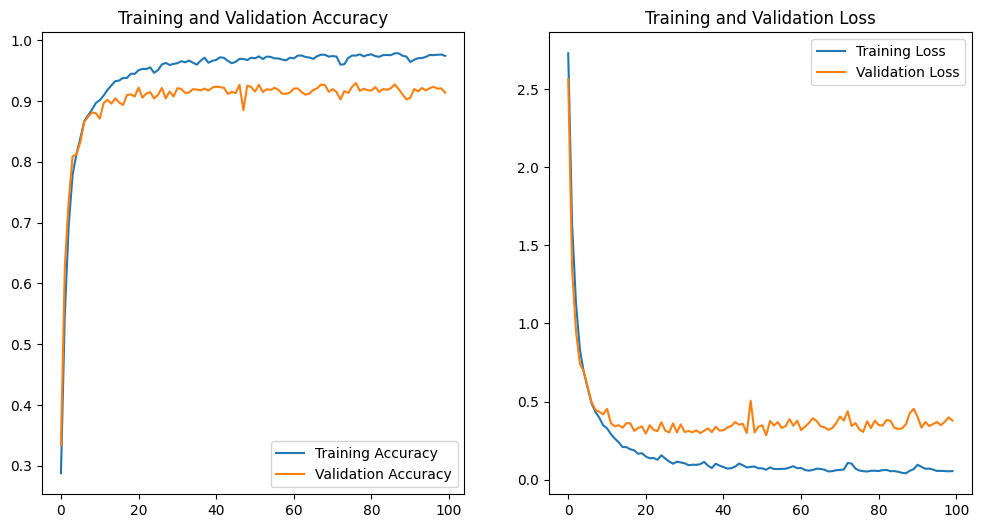

In [ ]:
# Plot Training and Validation Accuracy & Loss
acc = detector.history['accuracy']
val_acc = detector.history['val_accuracy']
loss = detector.history['loss']
val_loss = detector.history['val_loss']

epochs_range = range(100)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        52
           1       0.59      0.48      0.53        27
           2       0.83      0.81      0.82        36
           3       0.00      0.00      0.00         2
           4       0.94      0.76      0.84        38
           5       1.00      1.00      1.00         5
           6       0.81      0.88      0.84        74
           7       0.94      0.96      0.95        53
           9       0.93      0.94      0.94       178
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00         4
          12       0.99      1.00      0.99        93
          13       0.93      0.98      0.96       116
          14       0.00      0.00      0.00         1
          15       0.85      0.94      0.89        31
          16       0.96      0.93      0.95        59
          17       0.50      0.50      0.50         2
          18       1.00    

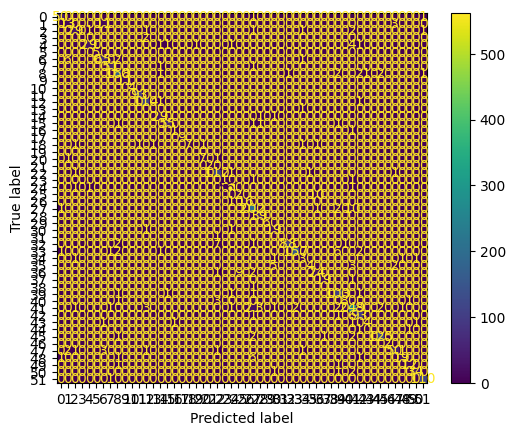

In [ ]:
# Predictions & Evaluation
predictions = np.argmax(model.predict(x_test), axis=1)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_test, predictions))
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9132 - loss: 0.4040
Test Accuracy: 91.37%
Test Loss: 0.3784


In [ ]:
# Training accuracy and loss over epochs
acc = detector.history['accuracy']
val_acc = detector.history['val_accuracy']
loss = detector.history['loss']
val_loss = detector.history['val_loss']

# Print final accuracy and loss values
print(f"Final Training Accuracy: {acc[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1] * 100:.2f}%")
print(f"Final Training Loss: {loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

Final Training Accuracy: 97.43%
Final Validation Accuracy: 91.37%
Final Training Loss: 0.0548
Final Validation Loss: 0.3784


In [ ]:
error = 1 - test_accuracy
print(f"Test Error: {error * 100:.2f}%")

Test Error: 8.63%


In [ ]:
# Add these imports to the top of the file (or a relevant code block)
from IPython import get_ipython
from IPython.display import display
from IPython import display as ipd # Importing display as ipd

import librosa
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder #Importing LabelEncoder

# Load the trained model
model = tf.keras.models.load_model("aquatic_species_model.keras")

# Function to preprocess the audio and make predictions
def predict_audio(audio_path, label_encoder):
    # Load audio
    audio, sample_rate = librosa.load(audio_path, sr=16000)

    # Ensure minimum length for FFT (Padding if needed)
    min_length = 2048
    if len(audio) < min_length:
        pad_length = min_length - len(audio)
        audio = np.pad(audio, (0, pad_length), mode='constant')

    # Dynamically adjust n_fft
    n_fft = min(2048, len(audio) // 2)
    hop_length = n_fft // 4

    # Extract MFCC Features
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=60, n_fft=n_fft, hop_length=hop_length)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Reshape for model input
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=0)
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=2)

    # Make prediction
    prediction = model.predict(mfccs_scaled)
    predicted_class = np.argmax(prediction)
    predicted_label = label_encoder.inverse_transform([predicted_class])[0] # Invert transform to get the label
    return predicted_label #Return the predicted label

#
# %%
# Function to extract Wav2Vec2.0 features
def extract_wav2vec_features(audio_path):
    audio, _ = librosa.load(audio_path, sr=16000)
    inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        features = wav2vec_model(**inputs).last_hidden_state.mean(dim=1).squeeze().numpy()
    return features

# %%
from google.colab import files

uploaded = files.upload()  # Upload an audio file

# Process uploaded file
for file_name in uploaded.keys():
    test_audio_path = file_name
    ipd.display(ipd.Audio(test_audio_path, rate=16000))  # Play audio

    # Extract features
    mfccs = librosa.feature.mfcc(y=librosa.load(test_audio_path, sr=16000)[0], sr=16000, n_mfcc=60)
    mfccs_scaled = np.mean(mfccs.T, axis=0)
    wav2vec_features = extract_wav2vec_features(test_audio_path)
    combined_features = np.hstack((mfccs_scaled, wav2vec_features))

    # Reshape for prediction
    input_features = np.expand_dims(combined_features, axis=0)
    input_features = np.expand_dims(input_features, axis=2)

    # Predict
    prediction = model.predict(input_features)
    predicted_class = np.argmax(prediction)
    predicted_label = le.inverse_transform([predicted_class])[0]
    confidence = np.max(prediction) * 100

    print(f"Predicted Class: {predicted_label}")
    print(f"Confidence: {confidence:.2f}%")
#
# %%
#Example of how to call predict_audio()
predicted_label = predict_audio("/content/drive/MyDrive/Colab Notebooks/5T/data/ClymeneDolphin/83006002.wav", le) #Using the label encoder
print(predicted_label)

Saving 94009046.wav to 94009046.wav


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
Predicted Class: Fraser'sDolphin
Confidence: 98.27%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
ClymeneDolphin


In [ ]:
# Required Imports
from IPython import get_ipython
from IPython.display import display
from IPython import display as ipd  # Importing display as ipd

import librosa
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder  # Importing LabelEncoder

# Load the trained model
model = tf.keras.models.load_model("aquatic_species_model.keras")

# Function to preprocess the audio and make predictions
def predict_audio(audio_path, label_encoder):
    # Load audio
    audio, sample_rate = librosa.load(audio_path, sr=16000)

    # Ensure minimum length for FFT (Padding if needed)
    min_length = 2048
    if len(audio) < min_length:
        pad_length = min_length - len(audio)
        audio = np.pad(audio, (0, pad_length), mode='constant')

    # Dynamically adjust n_fft
    n_fft = min(2048, len(audio) // 2)
    hop_length = n_fft // 4

    # Extract MFCC Features
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=60, n_fft=n_fft, hop_length=hop_length)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Reshape for model input
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=0)
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=2)

    # Make prediction
    prediction = model.predict(mfccs_scaled)
    predicted_class = np.argmax(prediction)
    predicted_label = label_encoder.inverse_transform([predicted_class])[0]  # Invert transform to get the label
    return predicted_label  # Return the predicted label


# Manually specify the audio file path for prediction
test_audio_path = "/content/drive/MyDrive/Colab Notebooks/5T/data/Beluga_WhiteWhale/49001002.wav"  # Change this to your file name

# Play the audio file
ipd.display(ipd.Audio(test_audio_path, rate=16000))

# Predict species
predicted_label = predict_audio(test_audio_path, le)  # Using the label encoder
print(f"Predicted Class: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
Predicted Class: Beluga_WhiteWhale


In [ ]:
## upload from file manager

In [ ]:
# Required Imports
from IPython.display import display
from IPython import display as ipd
import librosa
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# Load the trained model
model = tf.keras.models.load_model("aquatic_species_model.keras")

# Function to preprocess the audio and make predictions
def predict_audio(audio_path, label_encoder):
    # Load audio
    audio, sample_rate = librosa.load(audio_path, sr=16000)

    # Ensure minimum length for FFT (Padding if needed)
    min_length = 2048
    if len(audio) < min_length:
        pad_length = min_length - len(audio)
        audio = np.pad(audio, (0, pad_length), mode='constant')

    # Dynamically adjust n_fft
    n_fft = min(2048, len(audio) // 2)
    hop_length = n_fft // 4

    # Extract MFCC Features
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=60, n_fft=n_fft, hop_length=hop_length)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Reshape for model input
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=0)
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=2)

    # Make prediction
    prediction = model.predict(mfccs_scaled)
    predicted_class = np.argmax(prediction)
    predicted_label = label_encoder.inverse_transform([predicted_class])[0]  # Invert transform to get the label
    return predicted_label  # Return the predicted label


# Upload the audio file
uploaded = files.upload()

# Process uploaded file
for file_name in uploaded.keys():
    test_audio_path = file_name  # Get uploaded file name

    # Play uploaded audio
    ipd.display(ipd.Audio(test_audio_path, rate=16000))

    # Predict species
    predicted_label = predict_audio(test_audio_path, le)
    print(f"Predicted Class: {predicted_label}")


Saving 95003019.wav to 95003019.wav


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
Predicted Class: FalseKillerWhale


In [ ]:
# Required Imports
from IPython.display import display
from IPython import display as ipd
import librosa
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# Load the trained model
model = tf.keras.models.load_model("aquatic_species_model.keras")

# Function to preprocess the audio and make predictions
def predict_audio(audio_path, label_encoder):
    # Load audio
    audio, sample_rate = librosa.load(audio_path, sr=16000)

    # Ensure minimum length for FFT (Padding if needed)
    min_length = 2048
    if len(audio) < min_length:
        pad_length = min_length - len(audio)
        audio = np.pad(audio, (0, pad_length), mode='constant')

    # Dynamically adjust n_fft
    n_fft = min(2048, len(audio) // 2)
    hop_length = n_fft // 4

    # Extract MFCC Features
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=60, n_fft=n_fft, hop_length=hop_length)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Reshape for model input
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=0)
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=2)

    # Make prediction
    prediction = model.predict(mfccs_scaled)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100  # Get confidence percentage
    predicted_label = label_encoder.inverse_transform([predicted_class])[0]  # Invert transform to get the label
    return predicted_label, confidence  # Return the predicted label and confidence


# Manually specify the audio file path for prediction
test_audio_path = "/content/drive/MyDrive/Colab Notebooks/5T/data/ClymeneDolphin/8300600E.wav"  # Change this to your file name

# Play the audio file
ipd.display(ipd.Audio(test_audio_path, rate=16000))

# Predict species
predicted_label, confidence = predict_audio(test_audio_path, le)  # Using the label encoder
print(f"Predicted Class: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
Predicted Class: ClymeneDolphin
Confidence: 100.00%


In [ ]:
# Required Imports
from IPython.display import display
from IPython import display as ipd
import librosa
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# Load the trained model
model = tf.keras.models.load_model("aquatic_species_model.keras")

# Function to preprocess the audio and make predictions
def predict_audio(audio_path, label_encoder):
    # Load audio
    audio, sample_rate = librosa.load(audio_path, sr=16000)

    # Ensure minimum length for FFT (Padding if needed)
    min_length = 2048
    if len(audio) < min_length:
        pad_length = min_length - len(audio)
        audio = np.pad(audio, (0, pad_length), mode='constant')

    # Dynamically adjust n_fft
    n_fft = min(2048, len(audio) // 2)
    hop_length = n_fft // 4

    # Extract MFCC Features
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=60, n_fft=n_fft, hop_length=hop_length)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # Reshape for model input
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=0)
    mfccs_scaled = np.expand_dims(mfccs_scaled, axis=2)

    # Make prediction
    prediction = model.predict(mfccs_scaled)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100  # Get confidence percentage
    predicted_label = label_encoder.inverse_transform([predicted_class])[0]  # Invert transform to get the label
    return predicted_label, confidence  # Return the predicted label and confidence


# Upload the audio file
uploaded = files.upload()

# Process uploaded file
for file_name in uploaded.keys():
    test_audio_path = file_name  # Get uploaded file name

    # Play uploaded audio
    ipd.display(ipd.Audio(test_audio_path, rate=16000))

    # Predict species
    predicted_label, confidence = predict_audio(test_audio_path, le)
    print(f"Predicted Class: {predicted_label}")
    print(f"Confidence: {confidence:.2f}%")


Saving 95003006.wav to 95003006.wav


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
Predicted Class: FalseKillerWhale
Confidence: 100.00%
